In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import matplotlib.pyplot as plt
import numpy as np
import json
from tqdm import tqdm

from darksirenpop.utilities.utils import *
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.gw_selection_effects import *
from darksirenpop.likelihood import load_quaia, prepare_functions, get_dz_and_jacobian
from darksirenpop.config import Config
from darksirenpop.hypersampler.hypersampler import log_likelihood

make_nice_plots()


opening existing popsummary file: /home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
LTHRESH_STRING = '44.5'
zmodel = 'madau'
thresh = f'{LTHRESH_STRING}_kulkarni'
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'

agn_json_path = f'{JSON_DIR}/real_output_{zmodel}{label}.json'
with open(agn_json_path, "r") as f:
	data = json.load(f)
	gw_evidence_dict = data[str(thresh)]

reweight_PE_json_path = PE_JSON_PATH_REWEIGHT_PATH
with open(reweight_PE_json_path, 'r') as f:
	reweight_PEdict = json.load(f)


In [3]:
log_llh_fixed = log_likelihood(np.array([3.3, 2.55, 6.1, 1]), LTHRESH_STRING, gw_evidence_dict, return_spline=True)
fagn_posterior = get_pdfs(log_llh_fixed(LOG_LLH_X_AX), integrate_axis=LOG_LLH_X_AX)


/home/lucas/Documents/PhD/darksirenpop/utilities/gw_selection_effects.py:224: RuntimeWarning: divide by zero encountered in log
  return np.log(z_pop(z)) + np.log(m_pop(m1, m2))


In [4]:
def get_config(theta):
	b, c, d = theta
	rate_param_dict = {'b': b, 'c': c, 'd': d}

	cfg = Config()
	cfg.RATE_PARAMETERS = rate_param_dict
	cfg.VERBOSE = False
	cfg.THREADING = False
	cfg.REAL_DATA = True
	cfg.OUTFILE = 'none'
	cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
	cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
	cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
	cfg.ZMIN = 0.000001
	cfg.ZMAX = 10
	cfg.AGN_ZMAX = 10
	cfg.AGN_ZCUT = 3.0
	cfg.AGN_ZPRIOR = LTHRESH_STRING
	cfg.LUM_THRESH = LTHRESH_STRING
	cfg.MASK_GALACTIC_PLANE = True
	cfg.ASSUME_PERFECT_REDSHIFT = False
	cfg.AGN_ZERROR = 'quaia'
	cfg.CORRECT_TIME_DILATION = True
	cfg.MERGER_RATE = 'madau'
	cfg.LABEL = 'samplinggwtc5'
	cfg.finalize()

	return cfg

cfg = get_config(theta=np.array([3.3, 2.55, 6.1]))
agn_posterior_dset, agn_ra, agn_dec, obs_agn_redshift, redshift_completeness = load_quaia(0, cfg)
(average_completeness, 
 average_redshift_completeness, 
 sky_coverage, 
 fc_of_z, 
 p_rate_of_z_agn, 
 p_rate_of_z_alt, 
 p_rate_of_z_agn_func, 
 PEprior, PEprior_func, 
 normed_agn_background_dist, 
 fc_and_rate_weighted_agn_background_dist, 
 jacobian, 
 dz) = prepare_functions(cfg, redshift_completeness)
sum_of_all_agn_posteriors = np.sum(agn_posterior_dset, axis=0)
nagn_norm = romb(sum_of_all_agn_posteriors, dx=dz)

if nagn_norm == 0:
	agn_redshift_population_prior = fc_and_rate_weighted_agn_background_dist
else:
	agn_redshift_population_prior = p_rate_of_z_agn * average_redshift_completeness * sum_of_all_agn_posteriors / nagn_norm + fc_and_rate_weighted_agn_background_dist
agn_redshift_population_prior /= romb(agn_redshift_population_prior * jacobian, dx=dz)

background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)


In [16]:
# SELECTION EFFECTS
N_det = 256
far_thr = 1
snr_thr = 10
sel = ((snr_inject > snr_thr) | (far_inject < far_thr))

z_sel = redshift_inject[sel]
m1s_sel = mass1_source_inject[sel]
m2s_sel = mass2_source_inject[sel]
cost1_sel = np.cos(spin1theta[sel])
cost2_sel = np.cos(spin2theta[sel])
spin1r_sel = spin1r[sel]
spin2r_sel = spin2r[sel]
spin1phi_sel = spin1phi[sel]
spin2phi_sel = spin2phi[sel]

lnspin_sel = spinpop_MAP_joint_prob_func(spin1phi_sel, spin2phi_sel, spin1r_sel, spin2r_sel, cost1_sel, cost2_sel)
lnm1m2_sel = masspop_MAP.log_joint_prob(m1s_sel, m2s_sel).detach().cpu().numpy()

z_int_ax = np.linspace(1e-6, 10, 1024+1)
dz = np.diff(z_int_ax)[0]
dVc_dz = lambda z: COSMO.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z)  # Compensated for time dilation
dVc_dz_intax = dVc_dz(z_int_ax)
dVc_dz_sel = dVc_dz(z_sel)

lnz_vol_sel = np.log(dVc_dz_sel)
w_sel = weights[sel]
lnprob_sel = lnprob[sel]

Tyr = (total_analysis_time * u.s).to(u.year).value


In [ ]:
unif_src_eval = uniform_source_frame(cfg.Z_INTEGRAL_AX)  # Not normalized, values in Mpc**3, but constants divide out
log_unif_src_sel = np.log(uniform_source_frame(z_sel))


def local_rate_density(zpop_func):
	'''
	This is Appendix C3 of Essick et al. (2025) - https://ui.adsabs.harvard.edu/abs/2025PhRvD.112j2001E/abstract
	Uses injection campaign: https://zenodo.org/records/19500052

	Units given by lnz_vol_sel, I use Gpc^-3 yr^-1
	'''

	# Step 1: sample expected number of detections
	E_i = np.random.gamma(shape=N_det, scale=1.0)

	# Step 2: sample hyperparameters from posterior to create population model (input for this function),
	#		  and then evaluate this on the detected injections z_e and phi_e
	lnf_sel = np.log(zpop_func(z_sel)) - log_unif_src_sel  # f(z_e | \Lambda), volume units Mpc^3 divide out against lnprob of injection campaign
	lnz_sel = lnz_vol_sel + lnf_sel  # dV/dz|_{z_e} / (1 + z_e) f(z_e | \Lambda), lnz_vol_sel now also provides the units
	lnp_sel = lnm1m2_sel + lnspin_sel + lnz_sel

	# Step 3: calculate local rate density by dividing out injected population, and applying weights for different observing runs
	MC_sum = np.sum( w_sel * np.exp(lnp_sel - lnprob_sel) ) / total_generated
	R_0 = E_i / Tyr / MC_sum
	return R_0


def pop2rate(fagn, agn_zpop, alt_zpop):
	'''
	We require p(z) \propto dV/dz (1+z)^{-1}

	Therefore, we factorize 
	dV/dz (1+z)^{-1} * [ agn_zpop * fagn + alt_zpop * (1 - fagn) ] / ( dV/dz (1+z)^{-1} ) 
	
	\equiv 
	
	dV/dz (1+z)^{-1} f(z | \Lambda)

	R(z) = R_0 f(z | \Lambda), I'm calling it psi in the code because it's the convention in the paper
	'''

	zpop_eval = agn_zpop * fagn + alt_zpop * (1 - fagn)
	zpop_interp = CubicSpline(cfg.Z_INTEGRAL_AX, zpop_eval, extrapolate=False)
	R_0_full = local_rate_density(zpop_interp)
	psi_z_full = zpop_eval / unif_src_eval
	R_z_full = R_0_full * psi_z_full  # Rate evolution = local rate * evolution function
	total_rate_full = romb(R_z_full * dVc_dz_intax, dx=dz)  # Integrated over volume

	psi_z_alt = alt_zpop / unif_src_eval
	psi_z_agn = agn_zpop / unif_src_eval

	# Calculate local merger rate per channel using: f_agn * R_total = int dz R_0_agn * psi_agn * dV/dz / (1 + z)
	R_0_alt = (1 - fagn) * total_rate_full / romb(psi_z_alt * dVc_dz_intax, dx=dz)
	R_0_agn = fagn * total_rate_full / romb(psi_z_agn * dVc_dz_intax, dx=dz)

	R_z_alt = R_0_alt * psi_z_alt
	R_z_agn = R_0_agn * psi_z_agn

	return R_z_full, R_z_alt, R_z_agn


<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1799398/1648578181.py:30: SyntaxWarning: invalid escape sequence '\p'
  We require p(z) \propto dV/dz (1+z)^{-1}


In [18]:
N = int(1000)
fsamps = sample_from_distribution(CubicSpline(LOG_LLH_X_AX, fagn_posterior), LOG_LLH_X_AX, N)

R_z_full_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
R_z_alt_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
R_z_agn_arr = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
for i, fsamp in tqdm( enumerate(fsamps), total=N ):
	R_z_full, R_z_alt, R_z_agn = pop2rate(fsamp, 
										agn_zpop=agn_redshift_population_prior, 
										alt_zpop=alt_redshift_population_prior)
	R_z_full_arr[i,:] = R_z_full
	R_z_alt_arr[i,:] = R_z_alt
	R_z_agn_arr[i,:] = R_z_agn


100%|██████████| 1000/1000 [00:54<00:00, 18.42it/s]


In [19]:
result_MD = PopulationResult(fname=LVK_HYPERPOSTERIOR_PATH)
md_bbh_z_grid, md_bb_Rz = result_MD.get_rates_on_grids('redshift')
md_bbh_z_grid = md_bbh_z_grid.reshape((md_bbh_z_grid.size, ))


opening existing popsummary file: /home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


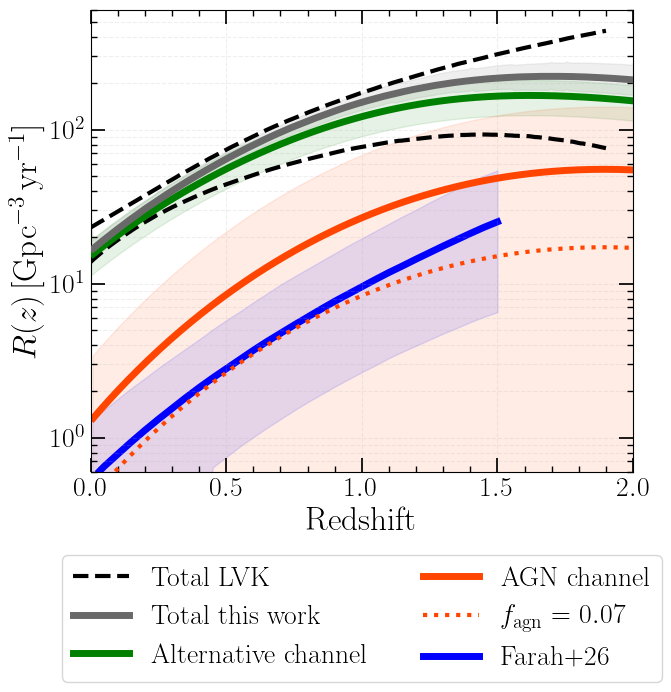

In [20]:
plt.figure(figsize=(7,6))

alpha_contour = 0.5
alpha_fill = 0.1
Nplot = 100

plt.plot(md_bbh_z_grid, np.quantile(md_bb_Rz, 0.05, axis = 0), linestyle='dashed', color='black', alpha=1, zorder=10, linewidth=3, label='Total LVK')
plt.plot(md_bbh_z_grid, np.quantile(md_bb_Rz, 0.95, axis = 0), linestyle='dashed', color='black', alpha=1, zorder=10, linewidth=3)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_full_arr, axis=0)[1:], linestyle='solid', color='dimgrey', alpha=1, linewidth=5, zorder=15, label='Total this work')
lower_Rfull = np.zeros(R_z_full_arr.shape[1])
upper_Rfull = np.zeros(R_z_full_arr.shape[1])
for i in range(R_z_full_arr.shape[1]):
	lower_Rfull[i], upper_Rfull[i] = hdi(R_z_full_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX, lower_Rfull, upper_Rfull, color='dimgrey', alpha=alpha_fill)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_alt_arr, axis=0)[1:], linestyle='solid', color='green', alpha=1, linewidth=5, zorder=10, label='Alternative channel')
lower_Rzalt = np.zeros(R_z_alt_arr.shape[1])
upper_Rzalt = np.zeros(R_z_alt_arr.shape[1])
for i in range(R_z_alt_arr.shape[1]):
	lower_Rzalt[i], upper_Rzalt[i] = hdi(R_z_alt_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX, lower_Rzalt, upper_Rzalt, color='green', alpha=alpha_fill)

plt.plot(cfg.Z_INTEGRAL_AX[1:], np.median(R_z_agn_arr, axis=0)[1:], linestyle='solid', color='orangered', alpha=1, linewidth=5, label='AGN channel')
lower_Rzagn = np.zeros(R_z_agn_arr.shape[1])
upper_Rzagn = np.zeros(R_z_agn_arr.shape[1])
for i in range(R_z_agn_arr.shape[1]):
	lower_Rzagn[i], upper_Rzagn[i] = hdi(R_z_agn_arr[:,i], cred_mass=0.9)
plt.fill_between(cfg.Z_INTEGRAL_AX[1:], lower_Rzagn[1:], upper_Rzagn[1:], color='orangered', alpha=alpha_fill)

_, _, R_z_agn_f26match = pop2rate(0.07, agn_zpop=agn_redshift_population_prior, alt_zpop=alt_redshift_population_prior)
plt.plot(cfg.Z_INTEGRAL_AX[1:], R_z_agn_f26match[1:], linestyle='dotted', color='orangered', linewidth=3, label=r'$f_{\rm agn} = 0.07$')

x1 = [0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,
	0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00,
	1.05,1.10,1.15,1.20,1.25,1.30,1.35,1.40,1.45,1.50]
y1 = [1.274, 1.512,1.786,2.095,2.431,2.831,3.273,3.770,4.343,5.039,5.784,
	6.590,7.564,8.619,9.856,11.109,12.476,14.011,15.734,17.670,19.701,
	21.965,24.489,27.304,30.221,33.695,37.295,41.581,45.692,50.210, 54.33]
y3 = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.640,0.748,0.874,1.007,1.156,1.317,1.501,1.698,1.907,2.141,
	2.388,2.662,2.946,3.285,3.610,3.952,4.327,4.738,5.150,5.618,6.085,6.529]
x2 = [0.0335,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,
	0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00,
	1.05,1.10,1.15,1.20,1.25,1.30,1.35,1.40,1.45,1.50]
y2 = [0.607, 0.650,0.781,0.937,1.115,1.317,1.545,1.812,2.111,2.440,2.801,
	3.214,3.689,4.204,4.755,5.379,6.063,6.834,7.674,8.556,9.540,
	10.636,11.815,13.030,14.423,15.907,17.543,19.277,21.183,23.193,25.198]

plt.fill_between(x1, y1, y3, color='blue', alpha=alpha_fill)
plt.plot(x2, y2, color='blue', linestyle='solid', label='Farah+26', linewidth=5, zorder=1)

plt.ylabel(r'$R(z) \, [\mathrm{Gpc^{-3} \, yr^{-1}}]$')
plt.xlabel('Redshift')
plt.xlim(0, 2)
plt.ylim(0.6, 6e2)
plt.semilogy()
plt.grid(alpha=0.2, which='minor', linestyle='dashed', axis='y')
plt.grid(alpha=0.2, which='major', linestyle='dashed', axis='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.savefig(f'{PLOT_DIR}/rates_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


In [ ]:
def get_alt_evidence(theta):    
	cfg = get_config(theta)

	with open(cfg.JSON_PATH, "r") as f:
		gw_path_dict = json.load(f)
	gw_keys = list(gw_path_dict.keys())
	gw_fnames = [gw_path_dict[key] for key in gw_keys]

	### Prepare functions for in the likelihood ###
	if cfg.CORRECT_TIME_DILATION:
		time_dilation_func = lambda z: time_dilation_correction(z)
	else: 
		time_dilation_func = lambda z: np.ones_like(z)
	time_dilation = time_dilation_func(cfg.Z_INTEGRAL_AX)
	zcut = z_cut(cfg.Z_INTEGRAL_AX, zcut=cfg.ZMAX)
	zrate_alt = merger_rate(cfg.Z_INTEGRAL_AX, cfg.MERGER_RATE_EVOLUTION, **cfg.MERGER_RATE_KWARGS)
	p_rate_of_z_alt = time_dilation * zrate_alt * zcut
	PEprior_func = lambda z: uniform_comoving_prior(z, cosmo=cfg.COSMO)
	PEprior = PEprior_func(cfg.Z_INTEGRAL_AX)
	dz, jacobian = get_dz_and_jacobian(cfg)

	### Calculate the integrals in the likelihood ###
	S_alt = {}
	for gw_idx, _ in enumerate(gw_fnames):
		gwkey = gw_keys[gw_idx]

		with open(cfg.REAL_ZPOSTS_JSON_PATH, "r") as f:
			gw_zpost_path_dict = json.load(f)
			gw_zpost_path = gw_zpost_path_dict[gwkey]
		with open(cfg.REAL_CW_ZPOSTS_JSON_PATH, "r") as f:
			gw_zpost_cw_path_dict = json.load(f)
			gw_zpost_cw_path = gw_zpost_cw_path_dict[gwkey]
		z, p = np.load(gw_zpost_path)
		z_cw, p_cw = np.load(gw_zpost_cw_path)
		gwpost_interp = CubicSpline(z, p, extrapolate=False)
		gw_redshift_posterior_marginalized_evaluated = gwpost_interp(cfg.Z_INTEGRAL_AX)
		gw_redshift_posterior_marginalized_evaluated[np.isnan(gw_redshift_posterior_marginalized_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros

		if not cfg.MASK_GALACTIC_PLANE:
			gw_redshift_posterior_marginalized_cw_evaluated = gw_redshift_posterior_marginalized_evaluated.copy()
		else:
			gwpost_interp_cw = CubicSpline(z_cw, p_cw, extrapolate=False)
			gw_redshift_posterior_marginalized_cw_evaluated = gwpost_interp_cw(cfg.Z_INTEGRAL_AX)
			gw_redshift_posterior_marginalized_cw_evaluated[np.isnan(gw_redshift_posterior_marginalized_cw_evaluated)] = 0  # NaNs outside extrapolation range changed to zeros'

		background_alt_distribution = uniform_comoving_prior(cfg.Z_INTEGRAL_AX, cosmo=cfg.COSMO)
		alt_redshift_population_prior = background_alt_distribution * p_rate_of_z_alt
		alt_redshift_population_prior /= romb(alt_redshift_population_prior * jacobian, dx=dz)
		S_alt[gwkey] = romb(y=gw_redshift_posterior_marginalized_evaluated / PEprior * alt_redshift_population_prior * jacobian, dx=dz)
	return S_alt


In [ ]:
N = int(1e5)
fsamps = sample_from_distribution(CubicSpline(LOG_LLH_X_AX, fagn_posterior), LOG_LLH_X_AX, N)

with open(agn_json_path, "r") as f:
	data = json.load(f)
	gw_evidence_dict = data[str(thresh)]

probdict = {}
max_p = -np.inf
for gwkey in gw_evidence_dict.keys():
	agn_evidence = gw_evidence_dict[gwkey]['S_agn_incat'] + gw_evidence_dict[gwkey]['S_agn_outcat']
	alt_evidence = gw_evidence_dict[gwkey]['S_alt']
	p = np.mean( fsamps * agn_evidence / (fsamps * agn_evidence + (1 - fsamps) * alt_evidence) )
	probdict[gwkey] = p
	if p > max_p:
		max_p = p

ranking = sorted(probdict.items(), key=lambda x: x[1], reverse=True)
print('AGN-origin probability')
for rank, (gwkey, prob) in enumerate(ranking, start=1):
	print(f"{rank:2d}. {gwkey:20s} {prob:.3f}")


p_none_samples = np.ones(len(fsamps))
for gwkey in gw_evidence_dict.keys():
	agn_evidence = (
		gw_evidence_dict[gwkey]['S_agn_incat']
		+ gw_evidence_dict[gwkey]['S_agn_outcat']
	)
	alt_evidence = gw_evidence_dict[gwkey]['S_alt']

	p_agn = (
		fsamps * agn_evidence
		/ (fsamps * agn_evidence + (1 - fsamps) * alt_evidence)
	)

	p_none_samples *= (1 - p_agn)

p_at_least_one = 1 - np.mean(p_none_samples)

print(f"P(at least one AGN event) = {p_at_least_one:.6f}")


AGN-origin probability
 1. GW230704_212616      0.250
 2. GW240824_205609      0.239
 3. GW241201_055758      0.236
 4. GW241229_155844      0.235
 5. GW231119_075248      0.234
 6. GW240621_214041      0.233
 7. GW240618_071627      0.233
 8. GW231230_170116      0.232
 9. GW231005_021030      0.232
10. GW240612_081540      0.231
11. GW230630_125806      0.229
12. GW241116_151753      0.229
13. GW240107_013215      0.227
14. GW230922_040658      0.227
15. GW190805_211137      0.226
16. GW240601_061200      0.223
17. GW240527_183429      0.222
18. GW230806_204041      0.219
19. GW250118_023225      0.217
20. GW230928_215827      0.217
21. GW231001_140220      0.215
22. GW230819_171910      0.213
23. GW241125_010116      0.213
24. GW230803_033412      0.212
25. GW231221_135041      0.211
26. GW230825_041334      0.211
27. GW241009_022835      0.211
28. GW230831_015414      0.210
29. GW231004_232346      0.209
30. GW231127_165300      0.206
31. GW230709_122727      0.205
32. GW250116_015

In [ ]:
ranking = sorted(
	probdict.items(),
	key=lambda x: x[1],
	reverse=True
)

ncols = 4
nrows = int(np.ceil(len(ranking) / ncols))

print(r"\begin{table*}[t]")
print(r"\centering")
print(r"\caption{Ranked AGN-origin probabilities for each GW event.}")
print(r"\label{tab:agn_probabilities}")

colspec = " @{\hspace{1cm}} ".join(["c l c"] * ncols)
print(rf"\begin{{tabular}}{{{colspec}}}")
print(r"\hline")

header = " & ".join(
	["Event & $P_{\\rm AGN}$"] * ncols
) + r" \\"
print(header)
print(r"\hline")

for i in range(nrows):
	row = []

	for j in range(ncols):
		idx = i + j * nrows

		if idx < len(ranking):
			rank = idx + 1
			gwkey, prob = ranking[idx]

			gwkey_string = f"{gwkey.split('_')[0]}\_{gwkey.split('_')[1]}"
			row.append(f"{gwkey_string} & {prob:.3f}")
		else:
			row.append("& &")

	print(" & ".join(row) + r" \\")

print(r"\end{tabular}")
print(r"\end{table*}")


\begin{table*}[t]
\centering
\caption{Ranked AGN-origin probabilities for each GW event.}
\label{tab:agn_probabilities}
\begin{tabular}{c l c @{\hspace{1cm}} c l c @{\hspace{1cm}} c l c @{\hspace{1cm}} c l c}
\hline
Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ & Event & $P_{\rm AGN}$ \\
\hline
GW230704\_212616 & 0.250 & GW231102\_071736 & 0.185 & GW241225\_082815 & 0.151 & GW241009\_084816 & 0.130 \\
GW240824\_205609 & 0.239 & GW240531\_075248 & 0.184 & GW231014\_040532 & 0.151 & GW240627\_131622 & 0.130 \\
GW241201\_055758 & 0.236 & GW241007\_082943 & 0.184 & GW240420\_175625 & 0.150 & GW190408\_181802 & 0.130 \\
GW241229\_155844 & 0.235 & GW191127\_050227 & 0.184 & GW200129\_065458 & 0.150 & GW240921\_201835 & 0.130 \\
GW231119\_075248 & 0.234 & GW240515\_005301 & 0.182 & GW240716\_034900 & 0.150 & GW191103\_012549 & 0.129 \\
GW240621\_214041 & 0.233 & GW230708\_230935 & 0.181 & GW230706\_104333 & 0.149 & GW191129\_134029 & 0.129 \\
GW240618\_071627 & 0.233 &

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_1776985/407188641.py:15: SyntaxWarning: invalid escape sequence '\h'
  colspec = " @{\hspace{1cm}} ".join(["c l c"] * ncols)
/tmp/ipykernel_1776985/407188641.py:35: SyntaxWarning: invalid escape sequence '\_'
  gwkey_string = f"{gwkey.split('_')[0]}\_{gwkey.split('_')[1]}"


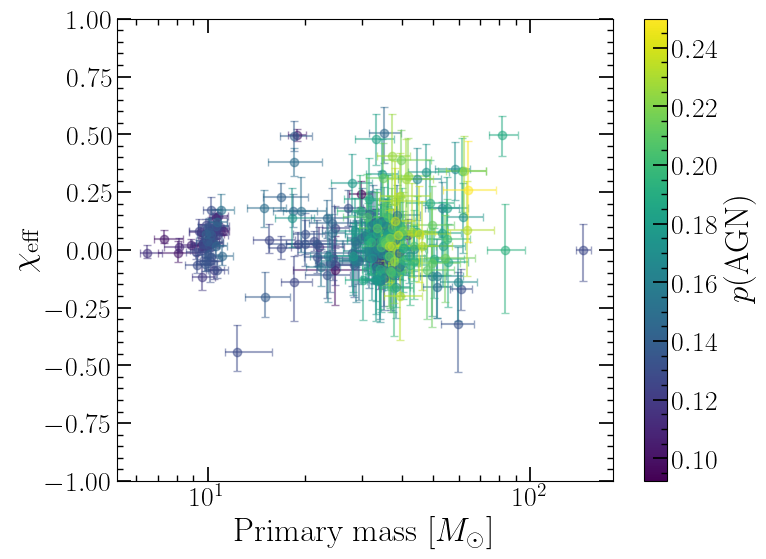

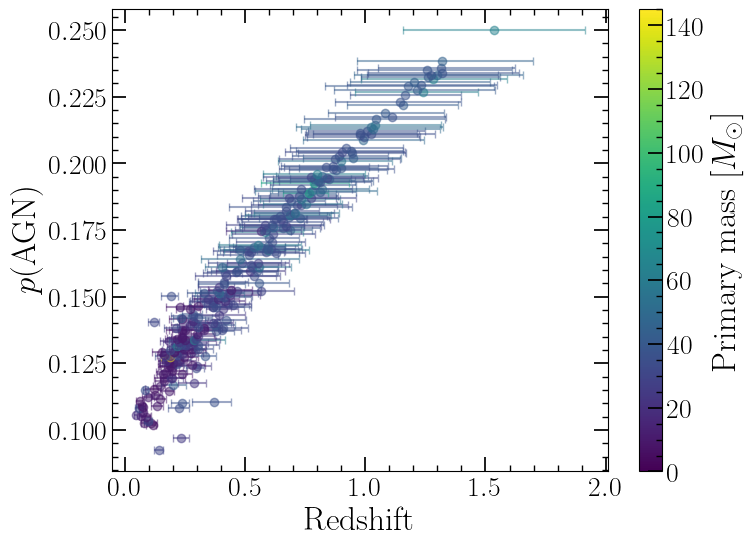

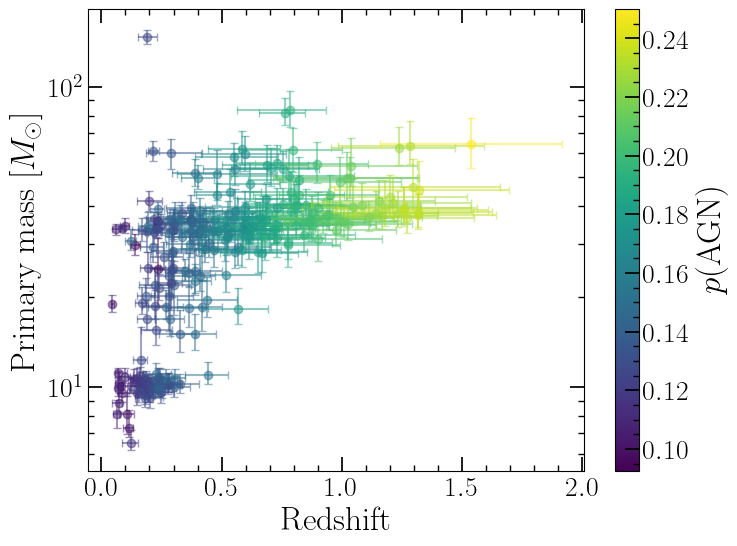

In [ ]:
norm = plt.Normalize(vmin=min(probdict.items(), key=lambda x: (x[1], x[0]))[1], 
					 vmax=max(probdict.items(), key=lambda x: (x[1], x[0]))[1])
norm_mass = plt.Normalize(vmin=0, vmax=145)

fig, ax = plt.subplots(figsize=(8,6))
fig2, ax2 = plt.subplots(figsize=(8,6))
fig3, ax3 = plt.subplots(figsize=(8,6))
for key in gw_evidence_dict.keys():

	# if key.split('_')[0] != 'GW190521':
	#     continue

	path = reweight_PEdict[key]
	
	with h5py.File(path, 'r') as f:
		approximant = list(f.keys())[0]
		posterior_samples = f[approximant]['posterior_samples']

		x = posterior_samples['mass_1_source']
		y = posterior_samples['chi_eff']
		z = posterior_samples['redshift']

		x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])
		y16, y50, y84 = np.quantile(y, [0.16, 0.50, 0.84])
		z16, z50, z84 = np.quantile(z, [0.16, 0.50, 0.84])
	
	ax3.errorbar(
		z50,
		x50,
		xerr=[[z50 - z16], [z84 - z50]],
		yerr=[[x50 - x16], [x84 - x50]],
		fmt='o',
		color=plt.cm.viridis(norm(probdict[key])),
		capsize=3,
		alpha=0.5,
		zorder=probdict[key]
	)

	ax2.errorbar(
		z50,
		probdict[key],
		xerr=[[z50 - z16], [z84 - z50]],
		fmt='o',
		color=plt.cm.viridis(norm_mass(x50)),
		capsize=3,
		alpha=0.5,
		zorder=probdict[key]
	)

	ax.errorbar(
		x50,
		y50,
		xerr=[[x50 - x16], [x84 - x50]],
		yerr=[[y50 - y16], [y84 - y50]],
		fmt='o',
		color=plt.cm.viridis(norm(probdict[key])),
		capsize=3,
		alpha=0.5,
		zorder=probdict[key]
	)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax, label=r"$p(\rm{AGN})$")
fig2.colorbar(plt.cm.ScalarMappable(norm=norm_mass, cmap="viridis"), ax=ax2, label=r"Primary mass [$M_{\odot}$]")
fig3.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=ax3, label=r"$p(\rm{AGN})$")
ax.semilogx()
ax.set_ylim(-1, 1)
ax.set_xlabel(r'Primary mass [$M_{\odot}$]')
ax.set_ylabel(r'$\chi_{\rm eff}$')
ax2.set_xlabel(r'Redshift')
ax2.set_ylabel(r'$p(\mathrm{AGN})$')
ax3.set_xlabel(r'Redshift')
ax3.set_ylabel(r'Primary mass [$M_{\odot}$]')
ax3.semilogy()
fig.savefig(f'{PLOT_DIR}/xeff_mass_{LTHRESH_STRING}.pdf', bbox_inches='tight')
fig2.savefig(f'{PLOT_DIR}/pagn_z_{LTHRESH_STRING}.pdf', bbox_inches='tight')
fig3.savefig(f'{PLOT_DIR}/mass_z_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


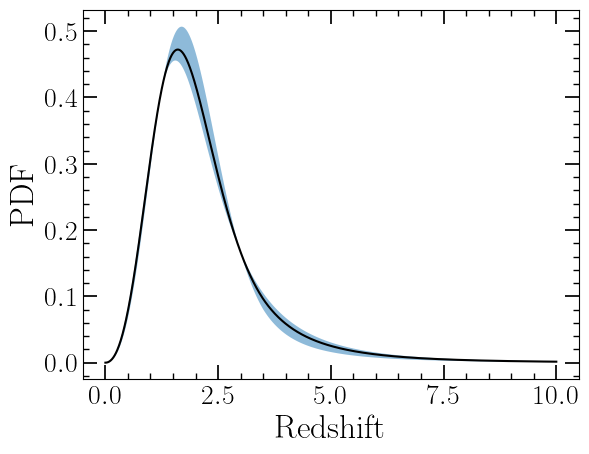

In [ ]:
zpop_posts = np.zeros((N, len(cfg.Z_INTEGRAL_AX)))
for i, fagn in enumerate(fsamps):
	zpop_posts[i,:] = fagn * agn_redshift_population_prior + (1 - fagn) * alt_redshift_population_prior

plt.figure()
plt.plot(cfg.Z_INTEGRAL_AX, np.median(zpop_posts, axis=0), color='black')
plt.fill_between(cfg.Z_INTEGRAL_AX, np.quantile(zpop_posts, 0.05, axis=0), np.quantile(zpop_posts, 0.95, axis=0), alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.show()
